# Zomato chennai Data Analysis

In [1]:
# !pip install plotly

In [2]:
 # import libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "svg"

In [3]:

# importing the dataset
raw_df = pd.read_csv("Zomato Chennai Listing 2020.csv")
raw_df.head()

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


## Getting Basic Information About Dataset

In [4]:
raw_df.shape   #no of rows & cols

(12032, 12)

In [5]:
# detailed info
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
raw_df.isnull().sum()    # null values count 

Zomato URL                  0
Name of Restaurant          0
Address                     0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [7]:
raw_df.describe()    # detailed description of entire dataset - descriptive analysis
# provides a summary of numerical statistics:

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


## cleaning the dataset

### remove redundunt rows data

In [8]:
# dropping columns which are not required for further analysis
raw_df.drop(['Zomato URL','Address'],axis=1, inplace=True)
raw_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


###  removing the null records

In [9]:
# checking for the null records
raw_df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [10]:
# Replacing the other null records with NA
raw_df.fillna(0,inplace=True)

In [11]:
# confirming all the null records are correct 
raw_df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

###  Converting the Datatypes of numerical columns to numeric datatype

In [12]:
raw_df['Dining Rating Count'].value_counts()

Dining Rating Count
Does not offer Dining        2603
Not enough Dining Reviews    2528
4                             339
5                             271
6                             248
                             ... 
877                             1
897                             1
872                             1
1197                            1
224                             1
Name: count, Length: 794, dtype: int64

In [13]:
raw_df['Dining Rating Count'] = raw_df['Dining Rating Count'].replace(to_replace=['Does not offer Dining','Not enough Dining Reviews'],value=0)

In [14]:
raw_df['Delivery Rating Count'].value_counts()

Delivery Rating Count
Not enough Delivery Reviews    3379
Does not offer Delivery        2252
0                               220
27                               34
37                               30
                               ... 
3530                              1
7705                              1
6374                              1
1773                              1
1617                              1
Name: count, Length: 2282, dtype: int64

In [15]:
raw_df['Delivery Rating Count'] = raw_df['Delivery Rating Count'].replace(to_replace=['Does not offer Delivery','Not enough Delivery Reviews'],value=0)

In [16]:
# changing data type of the numerical columns
raw_df['Dining Rating Count']=raw_df['Dining Rating Count'].astype('int64')
raw_df['Delivery Rating Count']=raw_df['Delivery Rating Count'].astype('int64')

In [17]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          12032 non-null  float64
 6   Dining Rating Count    12032 non-null  int64  
 7   Delivery Rating        12032 non-null  float64
 8   Delivery Rating Count  12032 non-null  int64  
 9   Features               12032 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 940.1+ KB


###  Removing the restaurant records whose Rating or Votes is 0

In [18]:
# finding those restaurant whose has 0 Rating or Votes 
useless_data = ((raw_df['Dining Rating']==0.0) &  (raw_df['Dining Rating Count']==0)) & ((raw_df['Delivery Rating']==0.0) &  (raw_df['Delivery Rating Count']==0))
raw_df[useless_data]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
1603,Erode Amman Mess,Thiruvanmiyur,"['Chettinad', ' South Indian', ' Kerala', ' Ch...",Invalid,600.0,0.0,0,0.0,0,"['Home Delivery', 'Indoor Seating', 'Table boo..."
2159,The Ultimate Brownie And Chocolate Place,Sholinganallur,"['Bakery', ' Desserts']",Invalid,350.0,0.0,0,0.0,0,"['Delivery Only', 'Desserts and Bakes']"
2419,Amudha Aunty's kitchen,Sholinganallur,"['Tamil', ' South Indian']",Invalid,250.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
2537,TN 03 CAFE,Tiruvottiyur,"['Sandwich', ' Fast Food', ' Ice Cream', ' Bev...",Invalid,200.0,0.0,0,0.0,0,['Delivery Only']
2542,Maggi Point,Tambaram,"['Fast Food', ' Street Food', ' Beverages']",['Masala Maggi'],500.0,0.0,0,0.0,0,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,0.0,0,0.0,0,"['Breakfast', 'Delivery Only']"


In [19]:
# performing negation of the useless dataset and then storing the correct data back in the raw_df DataFrame
# this permanently remove the wrong data from the original dataframe
raw_df=raw_df[~useless_data]

In [20]:
for i in raw_df.columns:
    print(f"{i} \n\n {raw_df[i].value_counts()} \n\n\n")

Name of Restaurant 

 Name of Restaurant
Domino's Pizza               66
CK's Bakery                  59
Lassi Shop                   55
Cafe Coffee Day              45
A2B - Adyar Ananda Bhavan    44
                             ..
The Alcove                    1
Saltlick by Gallop            1
Best Pizza                    1
Les Amis                      1
CK's Bakery & Cafe            1
Name: count, Length: 5768, dtype: int64 



Location 

 Location
Porur                                       270
Velachery                                   255
T. Nagar                                    235
Anna Nagar East                             227
Ambattur                                    213
                                           ... 
IBIS Hotel, Old Mahabalipuram Road (OMR)      1
The Slate                                     1
Eat And Pack, Ambattur                        1
The Pride Hotel, Kilpauk                      1
Chandra Metro Mall, Virugambakkam             1
Name: count, L

###  Working on 'Name' column

In [21]:
raw_df['Name of Restaurant'].value_counts()

Name of Restaurant
Domino's Pizza               66
CK's Bakery                  59
Lassi Shop                   55
Cafe Coffee Day              45
A2B - Adyar Ananda Bhavan    44
                             ..
The Alcove                    1
Saltlick by Gallop            1
Best Pizza                    1
Les Amis                      1
CK's Bakery & Cafe            1
Name: count, Length: 5768, dtype: int64

In [22]:
# Removing the irrelevant text from the region column 
raw_df['Name of Restaurant'] = raw_df['Name of Restaurant'].str.replace('[a-zA-Z].+-','',regex=True)
raw_df['Name of Restaurant']=raw_df['Name of Restaurant'].str.strip()

In [23]:
raw_df['Name of Restaurant'].value_counts()

Name of Restaurant
Domino's Pizza               66
CK's Bakery                  59
Lassi Shop                   55
Cafe Coffee Day              45
Adyar Ananda Bhavan          44
                             ..
Alagappa Chettinadu Hotel     1
Tarte Tatin                   1
Hotel Al Reem                 1
Divya Chettinad Hotel         1
Area Fast Food                1
Name: count, Length: 5659, dtype: int64

###  Working on Top Dishes column 

In [24]:
raw_df['Top Dishes'].value_counts()

Top Dishes
Invalid                                                                                                                                6091
['Biryani']                                                                                                                              30
['Coffee']                                                                                                                               14
['Chicken Biryani']                                                                                                                      12
['Sandwich']                                                                                                                             11
                                                                                                                                       ... 
['Burgers', ' Sandwich', ' Beef Burger', ' Burger Combo', ' French Fries', ' Cheese Corn Nuggets']                                        1
['Fish', 

In [25]:
raw_df['Top Dishes'] = raw_df['Top Dishes'].replace('Invalid','Not Mentioned')
raw_df['Top Dishes'].value_counts()

Top Dishes
Not Mentioned                                                                                                                          6091
['Biryani']                                                                                                                              30
['Coffee']                                                                                                                               14
['Chicken Biryani']                                                                                                                      12
['Sandwich']                                                                                                                             11
                                                                                                                                       ... 
['Burgers', ' Sandwich', ' Beef Burger', ' Burger Combo', ' French Fries', ' Cheese Corn Nuggets']                                        1
['Fish', 

###  Working on price column 

In [34]:
# convert price for 2 into price for 1
raw_df['Price for 2']

0         500.0
1        1000.0
2         500.0
3         500.0
4         450.0
          ...  
11901     500.0
11914     200.0
11953     300.0
11959     350.0
11960     350.0
Name: Price for 2, Length: 8481, dtype: float64

###  Working on  column 

###  removing Duplicate records

In [26]:
# finding all duplicate records
raw_df[raw_df.duplicated()]    # No duplicate records

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features


###  copying the cleaned data into a new DataFrame

In [27]:
zomato_chennai_df = raw_df.copy()
zomato_chennai_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"


In [28]:
zomato_chennai_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8481 entries, 0 to 11960
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     8481 non-null   object 
 1   Location               8481 non-null   object 
 2   Cuisine                8481 non-null   object 
 3   Top Dishes             8481 non-null   object 
 4   Price for 2            8481 non-null   float64
 5   Dining Rating          8481 non-null   float64
 6   Dining Rating Count    8481 non-null   int64  
 7   Delivery Rating        8481 non-null   float64
 8   Delivery Rating Count  8481 non-null   int64  
 9   Features               8481 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 728.8+ KB


# Performing Exploratory Data Analysis

## 1. how many restaurants are in Chennai for each type of cuisine?

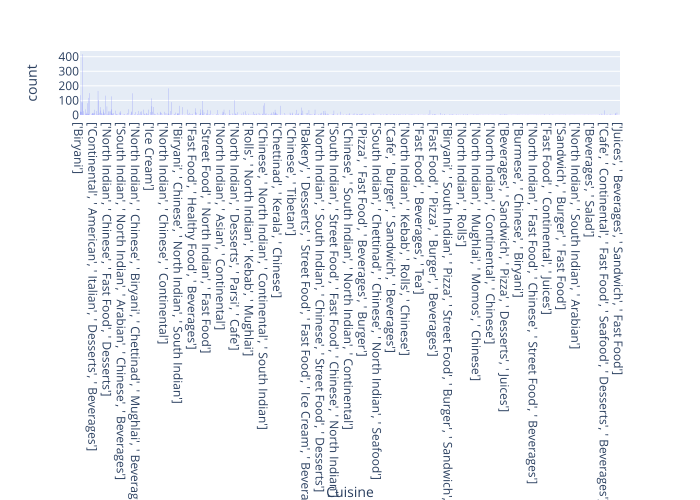

In [31]:
fig=px.histogram(zomato_chennai_df,x='Cuisine')
fig.show()